In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import mysql.connector 
import warnings
from scipy import stats
from scipy.stats import ttest_ind

warnings.filterwarnings('ignore')


In [2]:
db=mysql.connector.connect(host='localhost',username='root',password='diksha',database='demo1')
cur=db.cursor()

In [3]:
query = 'select * from vendor_sales_summary'

cur.execute(query)
data = cur.fetchall()   # MUST read results
df=pd.DataFrame(data,columns=['VendorNumber', 'VendorName', 'Brand', 'Description', 'ActualPrice',
       'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollars',
       'PurchasePrice', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalSalesExciseTax', 'TotalFreightCost',
       'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesPurchaseRAtio'])
df

,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,PurchasePrice,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalSalesExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRAtio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080.0,3811251.60,26.27,142049.0,5.101920e+06,672819.341167,260999.198781,68601.68,1.290668e+06,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038.0,3804041.22,23.19,160247.0,4.819073e+06,561512.375851,294438.657920,144929.24,1.015032e+06,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407.0,3418303.68,18.24,187140.0,4.538121e+06,461140.145689,343854.067793,123780.22,1.119817e+06,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682.0,3261197.94,16.17,200412.0,4.475973e+06,420050.005789,368242.797294,257032.07,1.214775e+06,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109.0,3023206.01,21.89,135838.0,4.223108e+06,545778.283312,249587.828808,257032.07,1.199902e+06,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,4.99,750.0,2.0,2.64,1.32,5.0,1.595000e+01,10.960000,0.550000,27100.41,1.331000e+01,83.448275,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.49,50.0,6.0,2.34,0.39,134.0,6.566000e+01,1.470000,7.040000,50293.62,6.332000e+01,96.436186,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.99,50.0,2.0,1.48,0.74,2.0,1.980000e+00,0.990000,0.100000,14069.87,5.000000e-01,25.252526,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.99,200.0,1.0,1.47,1.47,72.0,1.432800e+02,77.610000,15.120000,257032.07,1.418100e+02,98.974037,72.000000,97.469388


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074317,167655.266047,0.000000,729.219982,5298.044970,28396.914894,5.101920e+06
TotalSalesPrice,10692.0,18793.783517,44952.773491,0.000000,289.709993,2857.799950,16059.562242,6.728193e+05


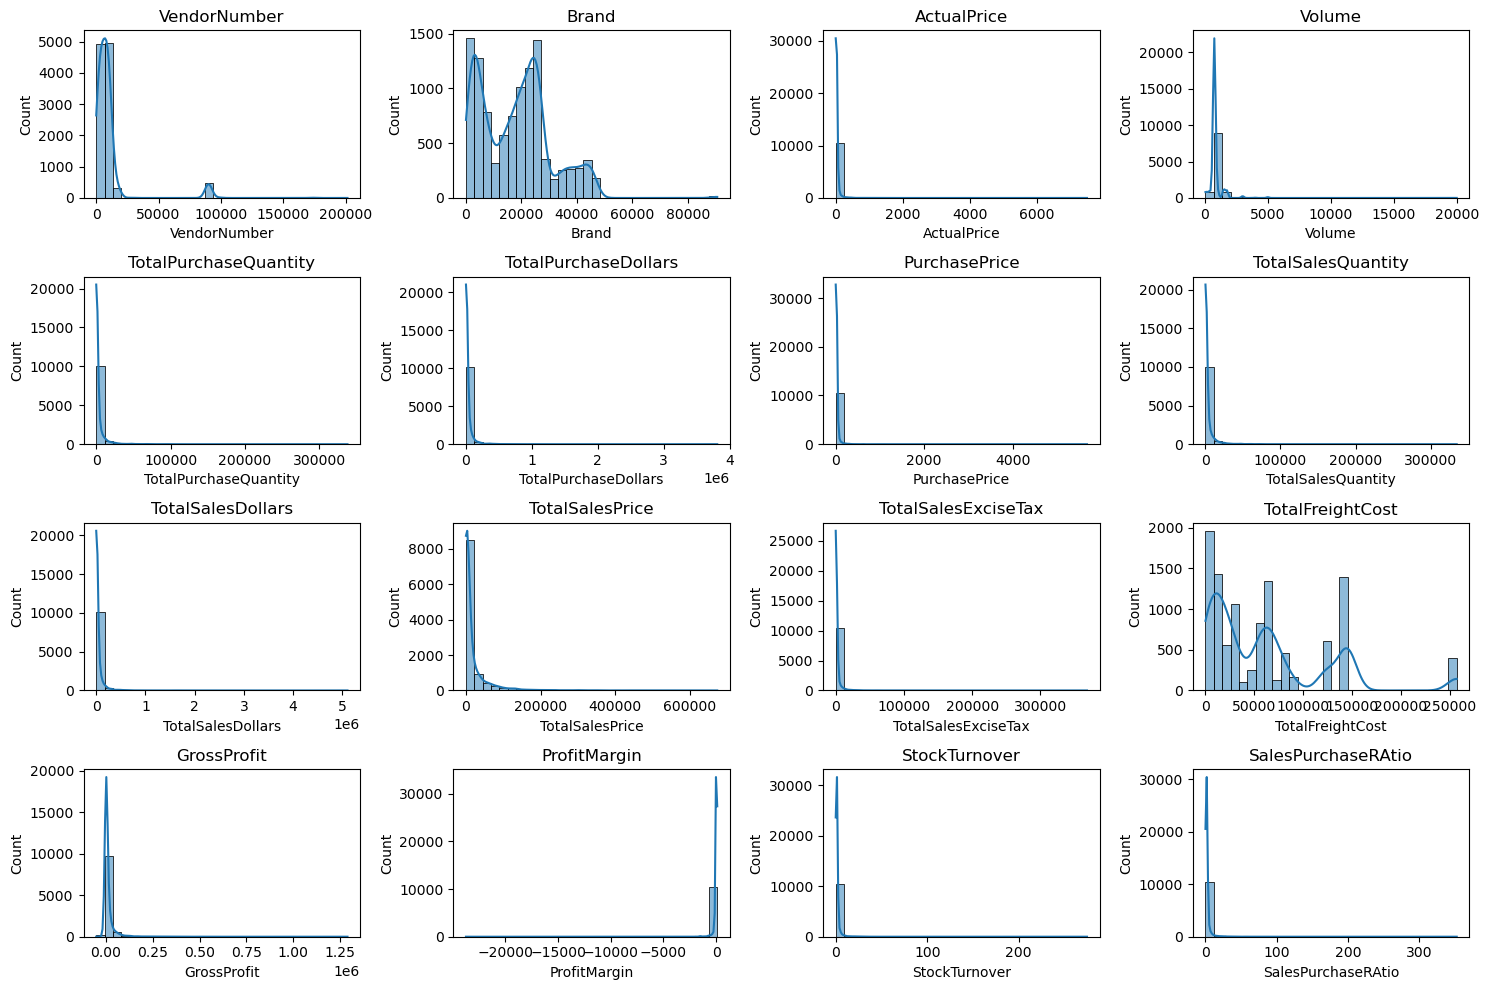

In [5]:
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

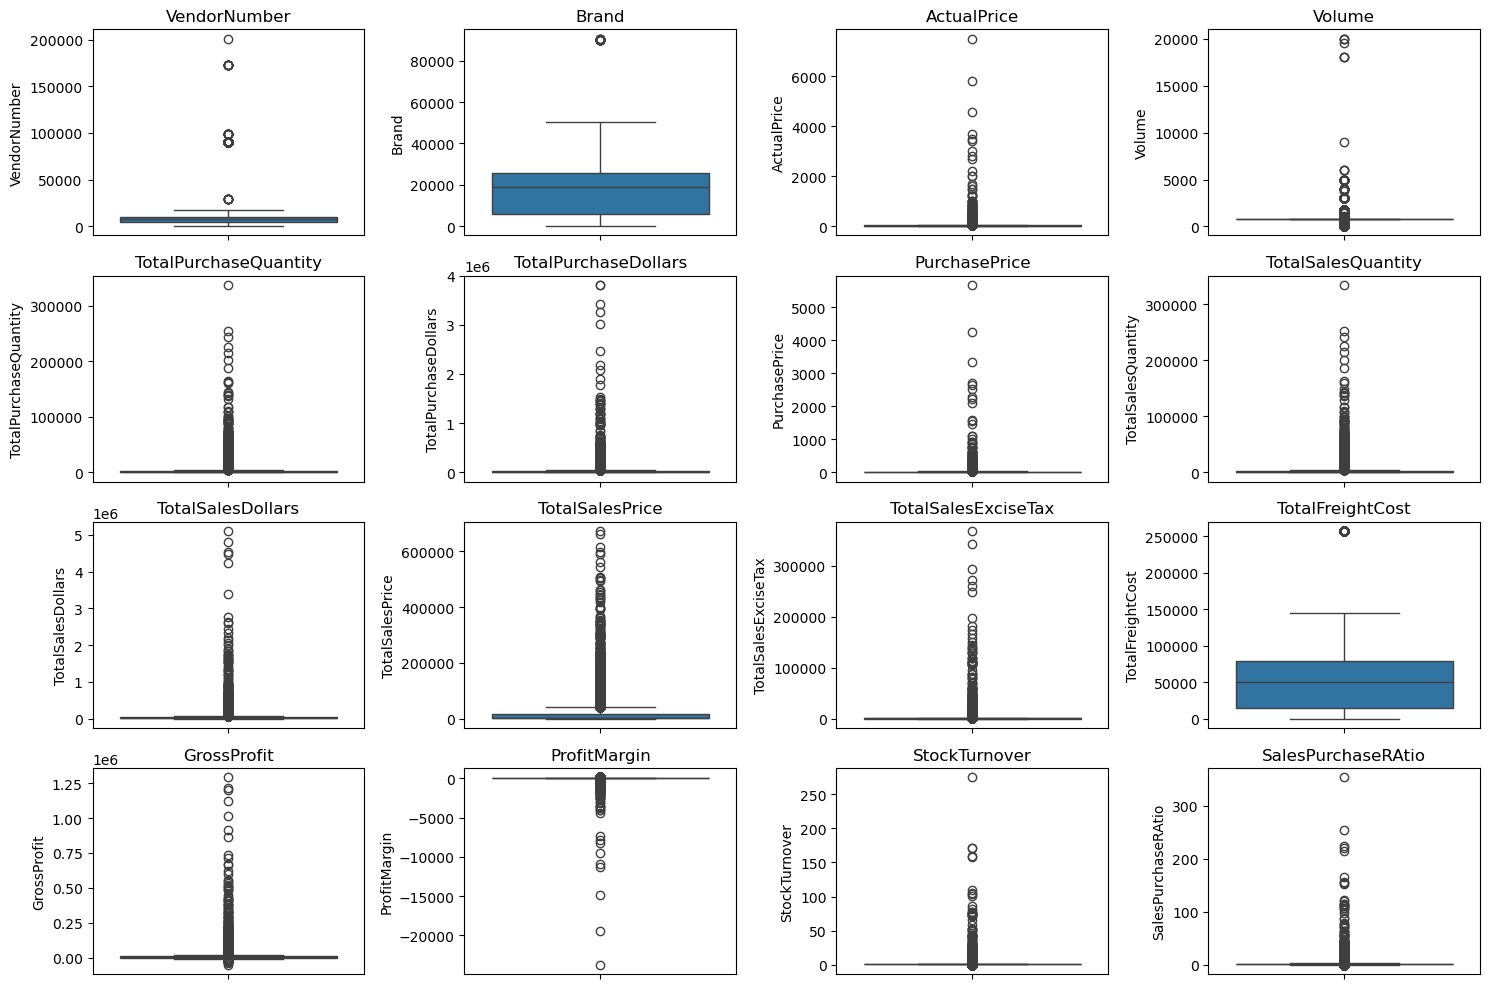

In [6]:
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights:

Negative & Zero Values:

>Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..

>Profit Margin: Has a minimum of-00, which suggests cases where revenue is zero or even lower than costs.


>Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

Outliers Indicated by High Standard Deviations:

>Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium
products.

>Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.

>Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [7]:
df=pd.read_sql_query('select * from vendor_sales_summary where GrossProfit>0 and ProfitMargin>0 and TotalSalesQuantity>0',db)

In [8]:
df

,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,PurchasePrice,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalSalesExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080.0,3811251.60,26.27,142049.0,5.101920e+06,672819.341167,260999.198781,68601.68,1.290668e+06,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038.0,3804041.22,23.19,160247.0,4.819073e+06,561512.375851,294438.657920,144929.24,1.015032e+06,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407.0,3418303.68,18.24,187140.0,4.538121e+06,461140.145689,343854.067793,123780.22,1.119817e+06,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682.0,3261197.94,16.17,200412.0,4.475973e+06,420050.005789,368242.797294,257032.07,1.214775e+06,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109.0,3023206.01,21.89,135838.0,4.223108e+06,545778.283312,249587.828808,257032.07,1.199902e+06,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,4.99,750.0,2.0,2.64,1.32,5.0,1.595000e+01,10.960000,0.550000,27100.41,1.331000e+01,83.448275,2.500000,6.041667
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.49,50.0,6.0,2.34,0.39,134.0,6.566000e+01,1.470000,7.040000,50293.62,6.332000e+01,96.436186,22.333333,28.059829
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.99,50.0,2.0,1.48,0.74,2.0,1.980000e+00,0.990000,0.100000,14069.87,5.000000e-01,25.252526,1.000000,1.337838
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.99,200.0,1.0,1.47,1.47,72.0,1.432800e+02,77.610000,15.120000,257032.07,1.418100e+02,98.974037,72.000000,97.469388


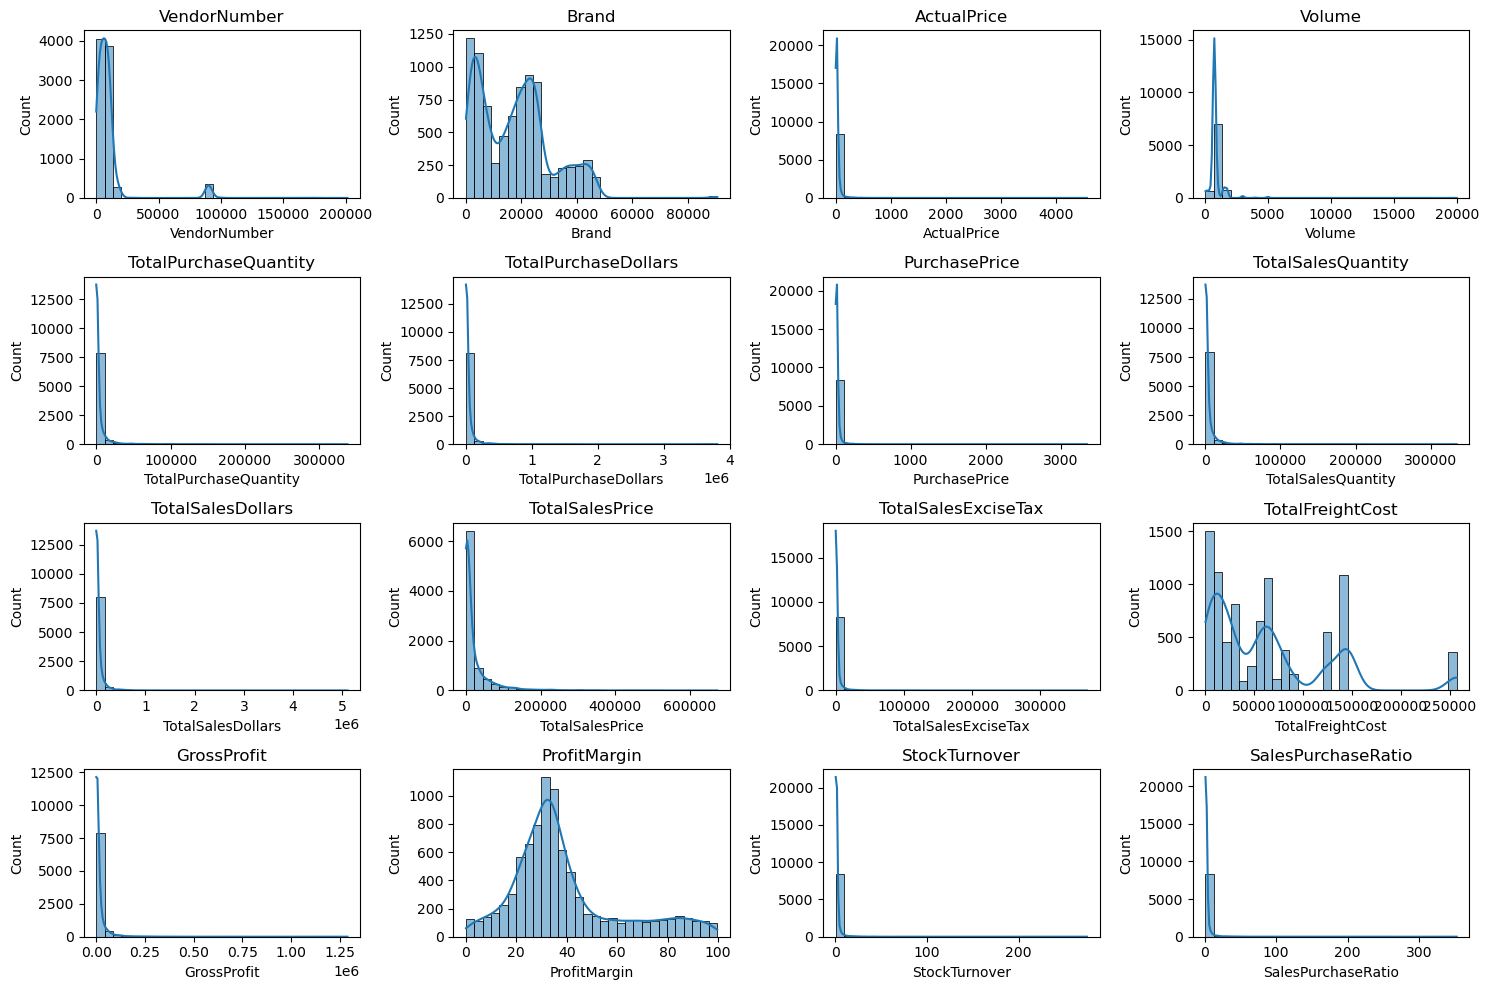

In [9]:
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

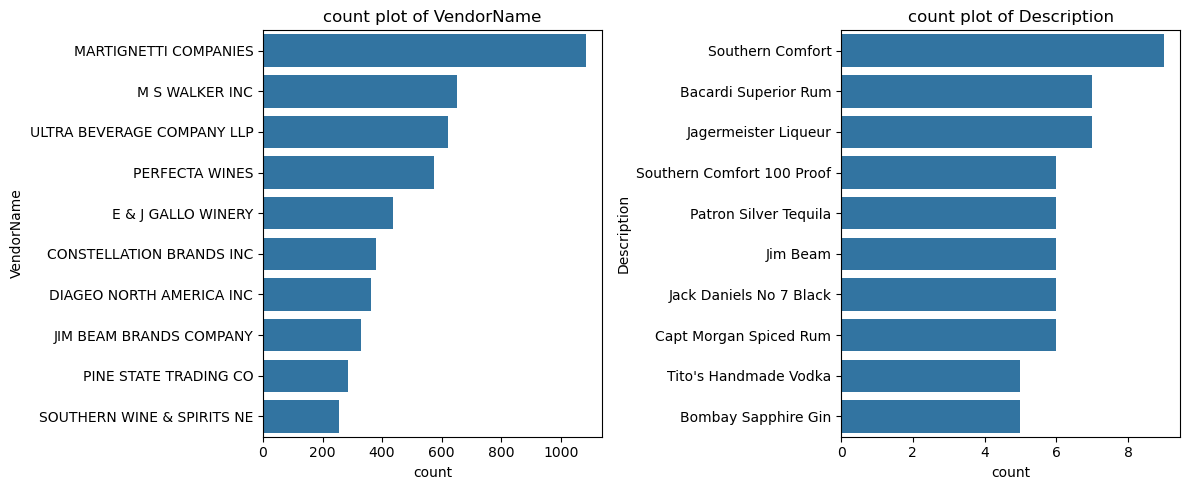

In [10]:
#count plot for categorical data
categorical_cols=['VendorName','Description']

plt.figure(figsize=(12,5))
for i,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()

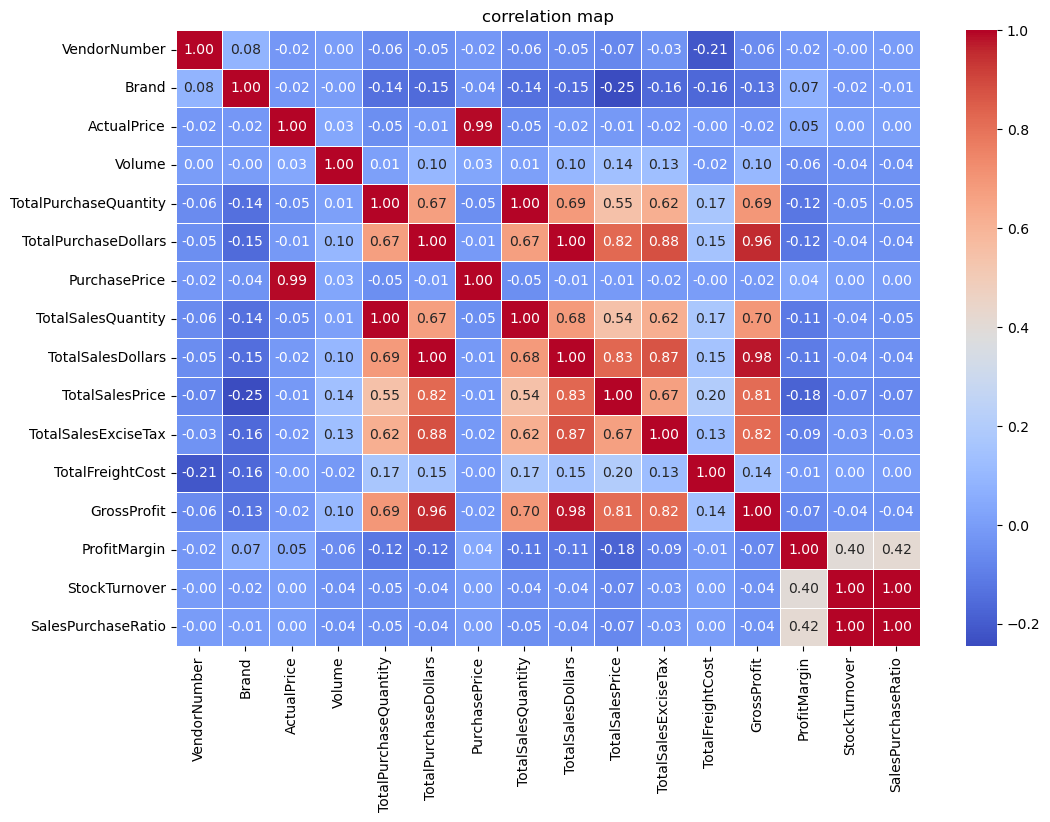

In [11]:
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidth=0.5)
plt.title('correlation map')
plt.show()

# Correlation Insights

PurchasePrice has weak correlations with TotalSales Dollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.

Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.

Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

Stock Turnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

advance analysis
TotalSalesDollars ↔ GrossProfit (~0.98)
→ profit driven by revenue volume

TotalPurchaseDollars ↔ TotalSalesDollars (~0.98)
→ buying more leads to selling more

ActualPrice ↔ PurchasePrice (~0.99)
→ pricing strategy tightly coupled

#    identify Brands that needs productional or pricing adjustments which exibits lower sales performace but higher profit margin 

In [12]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [13]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [16]:
target_brand=brand_performance[
    (brand_performance['TotalSalesDollars']<=low_sales_threshold) &
    (brand_performance['ProfitMargin']>=high_margin_threshold)
]

print('Brands with low sales but high profit margins:')
display(target_brand.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.990000,66.466466
2369,Debauchery Pnt Nr,11.580000,65.975820
2070,Concannon Glen Ellen Wh Zin,15.950000,83.448275
2188,Crown Royal Apple,27.859999,89.806173
6237,Sauza Sprklg Wild Berry Marg,27.959999,82.153075
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.679998,76.747312
2271,Dad's Hat Rye Whiskey,538.890007,81.851584
57,A Bichot Clos Marechaudes,539.939995,67.740860
6245,Sbragia Home Ranch Merlot,549.750000,66.444748


In [17]:
brand_performace=brand_performance[brand_performance['TotalSalesDollars']<10000]

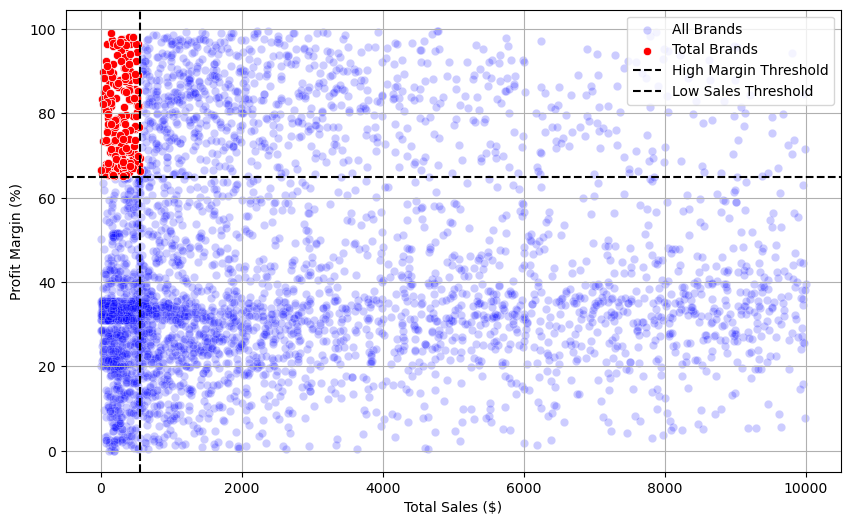

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performace,x='TotalSalesDollars',y='ProfitMargin',color='blue',label='All Brands',alpha=0.2)
sns.scatterplot(data=target_brand,x='TotalSalesDollars',y='ProfitMargin',color='red',label='Total Brands')

plt.axhline(high_margin_threshold,linestyle='--',color='black',label='High Margin Threshold')
plt.axvline(low_sales_threshold,linestyle='--',color='black',label='Low Sales Threshold')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')

plt.legend()
plt.grid(True)
plt.show()

# which vendors and brands demonstrate the highest sales performance

In [19]:
def format_dollars(value):
    if value>1_000_000:
        return f'{value/1_000_000:.2f}M'
    elif value >=1_000:
        return f'{value/1_000:.2f}k'
    else:
        return str(value)

In [20]:
top_vendor=df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands=df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)
top_vendor

VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.933036e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: TotalSalesDollars, dtype: float64

In [21]:
top_brands.apply(lambda x:format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

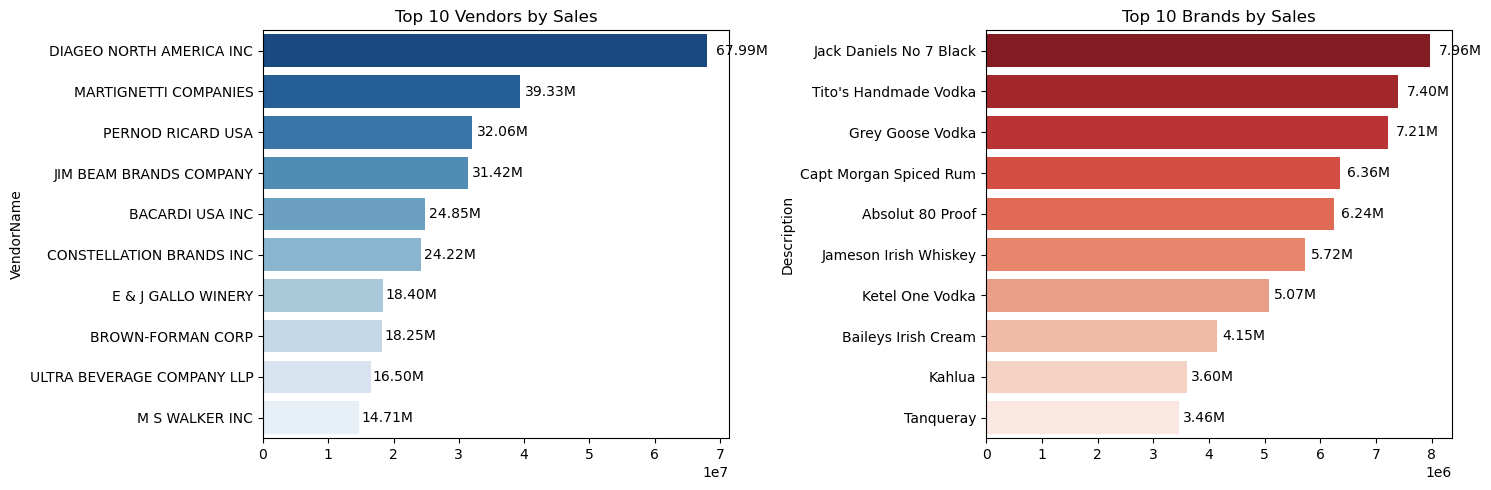

In [22]:
plt.figure(figsize=(15, 5))

# ----------------------------
# Plot 1: Top Vendors
# ----------------------------
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendor.index,
    x=top_vendor.values,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")

# Add labels on bars
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# ----------------------------
# Plot 2: Top Brands
# ----------------------------
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")

# Add labels on bars
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()


# which vendors contribute the most to total purchase dollars

In [23]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [24]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [25]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [26]:
top_vendors=vendor_performance.head(10)

top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [27]:
top_vendors['cumulativeContribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,cumulativeContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


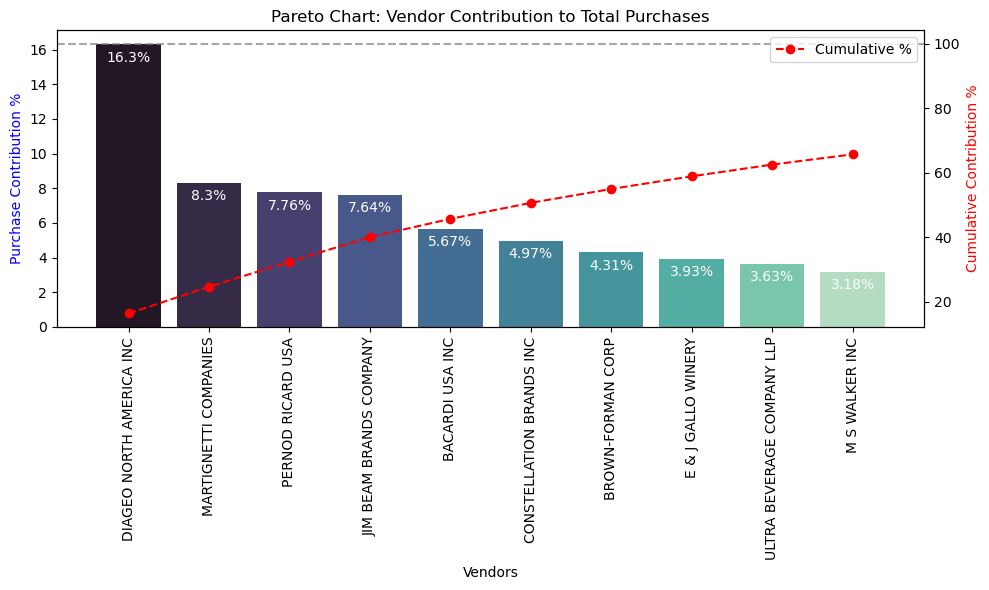

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10, 6))

# ---------------------------
# Bar Plot (Contribution %)
# ---------------------------
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

# Add percentage labels on bars
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(
        i,
        value - 1,
        str(value) + '%',
        ha='center',
        fontsize=10,
        color='white'
    )

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax1.set_xlabel('Vendors')

# ---------------------------
# Line Plot (Cumulative %)
# ---------------------------
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['cumulativeContribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative %'
)

ax2.set_ylabel('Cumulative Contribution %', color='red')
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

ax2.legend(loc='upper right')

plt.title('Pareto Chart: Vendor Contribution to Total Purchases')

plt.tight_layout()
plt.show()


# how much of total procurement is depended on the top vendors ?

In [29]:
print(f'Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %')


Total Purchase Contribution of top 10 vendors is 65.69 %


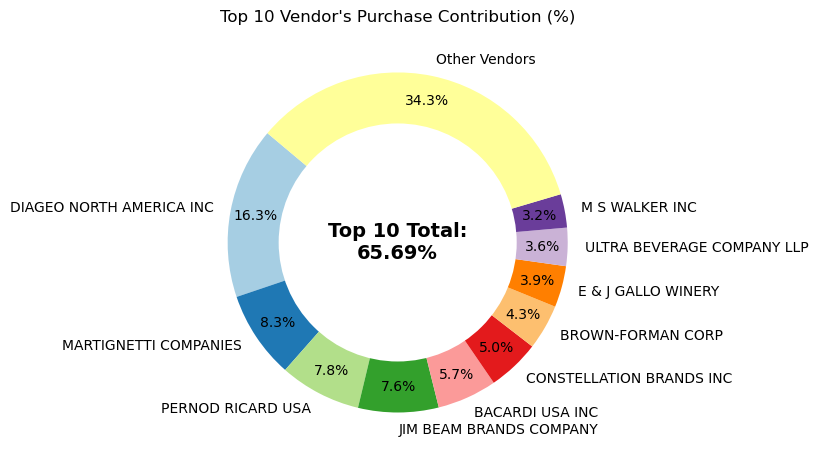

In [30]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)


fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw white circle in center (Donut effect)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add total contribution text in center
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")

plt.tight_layout()
plt.show()


# Does purchasing in bulk reduce the unit price and what is the optimal purchase volume for cost saving ?

In [31]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [32]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['Small','Medium','Large'])

In [33]:
df

,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,PurchasePrice,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalSalesExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080.0,3811251.60,26.27,142049.0,5.101920e+06,672819.341167,260999.198781,68601.68,1.290668e+06,25.297693,0.979108,1.338647,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038.0,3804041.22,23.19,160247.0,4.819073e+06,561512.375851,294438.657920,144929.24,1.015032e+06,21.062810,0.976890,1.266830,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407.0,3418303.68,18.24,187140.0,4.538121e+06,461140.145689,343854.067793,123780.22,1.119817e+06,24.675786,0.998575,1.327594,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682.0,3261197.94,16.17,200412.0,4.475973e+06,420050.005789,368242.797294,257032.07,1.214775e+06,27.139908,0.993703,1.372493,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109.0,3023206.01,21.89,135838.0,4.223108e+06,545778.283312,249587.828808,257032.07,1.199902e+06,28.412764,0.983556,1.396897,21.89,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,4.99,750.0,2.0,2.64,1.32,5.0,1.595000e+01,10.960000,0.550000,27100.41,1.331000e+01,83.448275,2.500000,6.041667,1.32,Small
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.49,50.0,6.0,2.34,0.39,134.0,6.566000e+01,1.470000,7.040000,50293.62,6.332000e+01,96.436186,22.333333,28.059829,0.39,Small
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.99,50.0,2.0,1.48,0.74,2.0,1.980000e+00,0.990000,0.100000,14069.87,5.000000e-01,25.252526,1.000000,1.337838,0.74,Small
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.99,200.0,1.0,1.47,1.47,72.0,1.432800e+02,77.610000,15.120000,257032.07,1.418100e+02,98.974037,72.000000,97.469388,1.47,Small


In [34]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


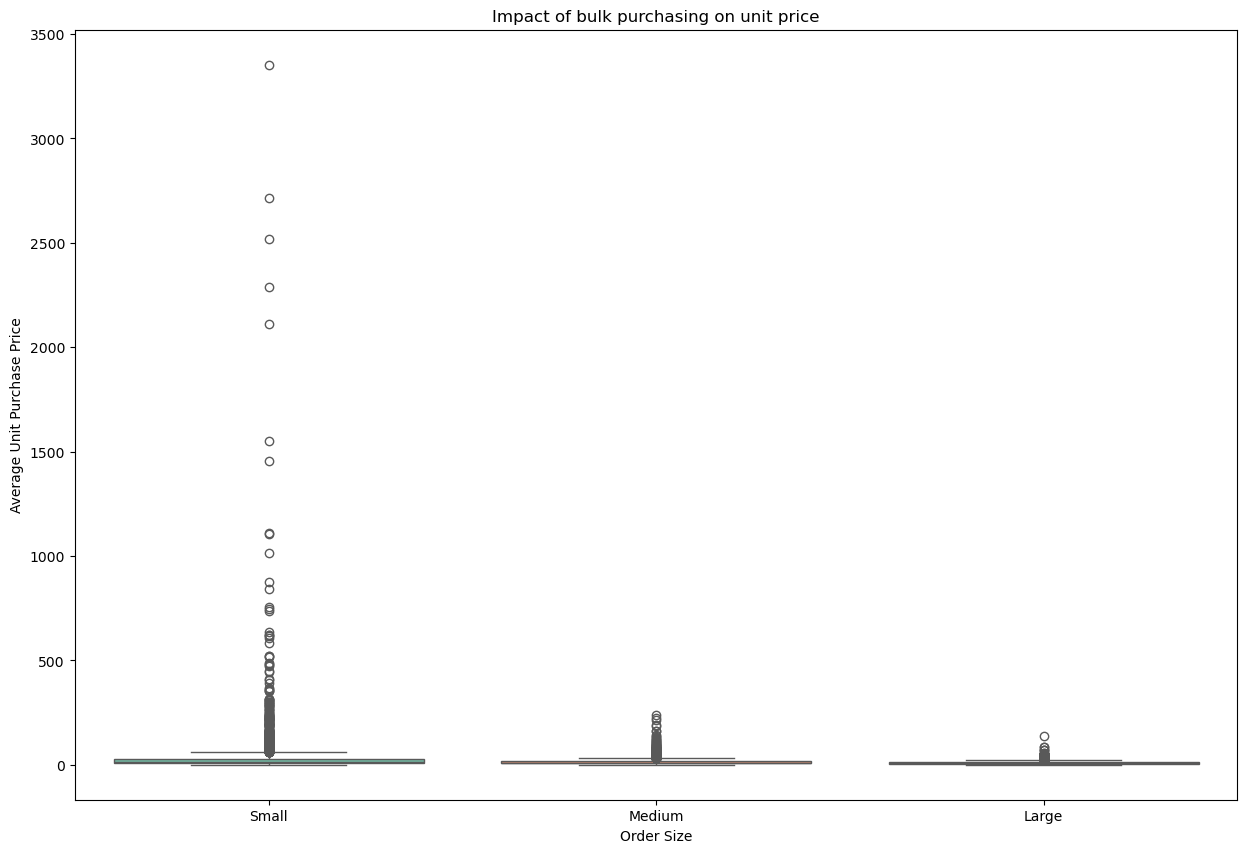

In [35]:
plt.figure(figsize=(15,10))
sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')
plt.title('Impact of bulk purchasing on unit price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')
plt.show()

Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.

The price difference between Small and Large orders is substantial (~72% reduction in unit cost).

This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

# which vendors have low inventory turnover , indicating excess stock and slow moving products ?

In [36]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


# how much capital is locked in unsold inventory per vendor and which vendor contribute the most to it

In [37]:
df['UnsoldInventoryValue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']
print('Total unsold Capital:',format_dollars(df['UnsoldInventoryValue'].sum()))

Total unsold Capital: 2.71M


In [38]:
inventory_value_per_vendor=df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by='UnsoldInventoryValue',ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue']=inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21k
46,JIM BEAM BRANDS COMPANY,554.67k
68,PERNOD RICARD USA,470.63k
116,WILLIAM GRANT & SONS INC,401.96k
30,E & J GALLO WINERY,228.28k
79,SAZERAC CO INC,198.44k
11,BROWN-FORMAN CORP,177.73k
20,CONSTELLATION BRANDS INC,133.62k
61,MOET HENNESSY USA INC,126.48k
77,REMY COINTREAU USA INC,118.60k


# what is the 95% confidence intervals for profit margins of top-proforming and low performing vendors

In [39]:
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

In [40]:
top_vendors=df[df['TotalSalesDollars']>=top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_threshold]['ProfitMargin'].dropna()

In [41]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2142, dtype: float64

In [42]:
def confidence_interval(data,confidence=0.95):
    mean_val=np.mean(data)
    std_err=np.std(data,ddof=1)/np.sqrt(len(data))
    t_critical=stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical*std_err
    return mean_val,mean_val-margin_of_error,mean_val+margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


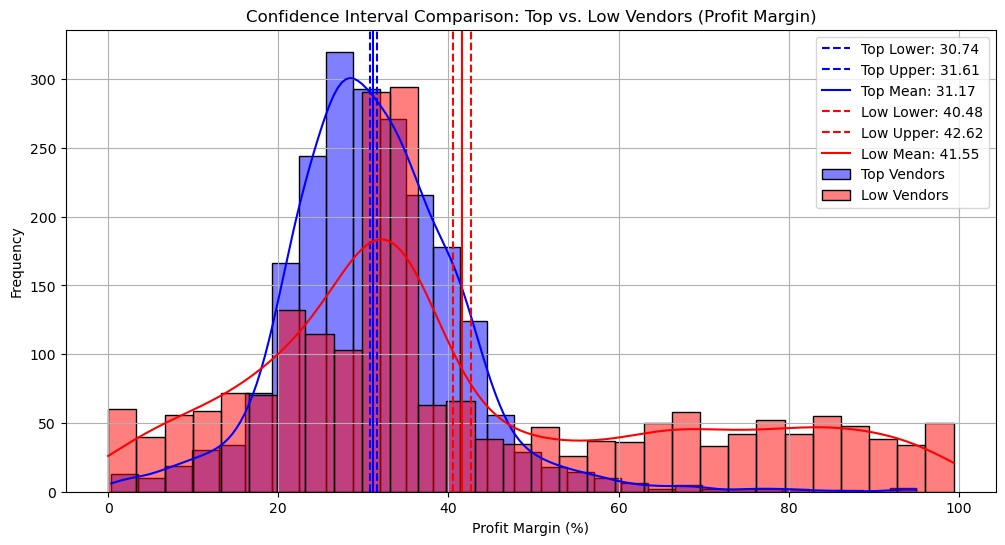

In [43]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")


plt.figure(figsize=(12, 6))

# -------------------
# Top Vendors Plot
# -------------------
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# -------------------
# Low Vendors Plot
# -------------------
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# -------------------
# Final Formatting
# -------------------
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()


plt.grid(True)
plt.show()


The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).

This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.

For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.

For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

# Is there a significant difference in profit margins between top performing and low performing vendors?

hypothesis:
Null Hypothesis: there is no significant difference in the mean profit margins of top performing and low performing vendors

Alternative Hypothesis: The mean profit margins of top performing and low performing vendors are significantly different

In [45]:
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

top_vendors=df[df['TotalSalesDollars']>=top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_threshold]['ProfitMargin'].dropna()

# perform two sample t-test
t_test,p_value=ttest_ind(top_vendors,low_vendors,equal_var=False)

print(f"T-statistic :{t_test:.4f},p_value:{p_value:.4f}")

if p_value<0.05:
    print('Reject H : there is a significant difference in profit margins between top and low performing vendors.')
else:
    print('Fail to Reject H : No significant difference in profit margins.')

T-statistic :-17.6440,p_value:0.0000
Reject H : there is a significant difference in profit margins between top and low performing vendors.


## Recommendations 
1. Focus on High-Performing Vendors

A small group of vendors contributes the majority of total sales and revenue.

Prioritize and strengthen relationships with top-performing vendors by offering incentives, better contracts, and consistent collaboration.

Impact:
Improves revenue stability and ensures continuous high performance.

2.Improve or Replace Low-Performing Vendors

Several vendors show very low contribution to overall sales.
Evaluate underperforming vendors to identify issues such as pricing, demand, or product quality. Provide improvement strategies or replace them if necessary.

Impact:
Eliminates inefficiencies and improves overall business performance.

3. Optimize Profit Margins

Profit margins vary significantly across vendors and products.

Identify vendors with high sales but low profit margins and optimize pricing strategies or reduce procurement costs.

Impact:
Increases overall profitability without necessarily increasing sales volume.

4. Reduce Dependency on Few Vendors

Revenue is heavily concentrated among a small number of vendors.
Encourage growth of mid-performing vendors and diversify the vendor base to balance contribution.

Impact:
Reduces business risk and ensures more stable operations.

5. Optimize Product & Brand Performance

Some brands/products perform significantly better than others.
Increase focus on high-performing products through better inventory management and promotions, while reconsidering low-performing ones.